In [1]:
import os
import re
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")
from config_io import load_multifield_from_disk
from experiment import build_bg_only_cfg
from bg_stage import run_bg_inference, train_bg_only


def _global_diag(x_true, x_hat):
    """Global reconstruction metrics (replaces the old ROI diagnostics)."""
    x_true = np.asarray(x_true); x_hat = np.asarray(x_hat)
    dr = float(x_true.max() - x_true.min()) or 1.0
    mse = float(np.mean((x_true - x_hat) ** 2))
    psnr = 20 * np.log10(dr) - 10 * np.log10(mse + 1e-12) if mse > 0 else 100.0
    max_err = float(np.max(np.abs(x_true - x_hat)))
    return {"psnr": psnr, "max_err": max_err}

pysz_path = r"/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_path not in sys.path:
    sys.path.append(pysz_path)
from pysz import SZ


def set_seed(seed=17):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 17   # shared seed for BOTH the BG pipeline (cfg.seed) and NeurLZ (set_seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda:0


In [2]:
# ==== 路径与数据（可按需改 TARGET_STEM / REL_SETTINGS）====
import sys
from pathlib import Path

base_path = Path(r"/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin").resolve()
base_path = base_path.as_posix() + "/"
sz_lib_path = r"/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
data_shape = (512, 512, 512)

TARGET_STEM = "temperature"
FIELD_FILES = [
    "temperature.f32",
    "velocity_z.f32",
    "baryon_density.f32",
    "velocity_x.f32",
    "velocity_y.f32",
    "dark_matter_density.f32"
]#    "temperature.f32", "dark_matter_density.f32",

REL_SETTINGS = [("r0", 1e-4), ("r1", 2e-4), ("r2", 3e-4),("r3", 4e-4),("r4", 5e-4),("r5", 6e-4),("r6", 1e-3)]
REL_ACTIVE_IDX = 0
REL_ERR_SZ_BITSTREAM = REL_SETTINGS[REL_ACTIVE_IDX][1]


def rel_sz_suffix(rel_err: float) -> str:
    return f"{rel_err:.0e}".replace("+", "")


def sz_bin_for_target(fname: str, rel_err: float) -> str:
    stem = Path(fname).stem
    return base_path + stem + "_rel" + rel_sz_suffix(rel_err) + ".sz"

fname = TARGET_STEM + ".f32"
gt_path = base_path + fname
aux_paths = [base_path + f for f in FIELD_FILES if f != fname]
sz_bin_path = sz_bin_for_target(fname, REL_ERR_SZ_BITSTREAM)

_sz_path = Path(sz_bin_path)
if not _sz_path.is_file():
    from pysz import SZ
    print("[save .sz] 压缩:", _sz_path)
    eng = SZ(sz_lib_path)
    vol = np.fromfile(gt_path, dtype=np.float32).reshape(data_shape)
    blob, cr = eng.compress(vol, 1, 0, REL_ERR_SZ_BITSTREAM, 0)
    del vol
    _sz_path.parent.mkdir(parents=True, exist_ok=True)
    _sz_path.write_bytes(blob)
    print("CR ≈", float(cr))

Xs, Xps = load_multifield_from_disk(
    gt_path=gt_path,
    aux_paths=aux_paths,
    sz_bin_path=sz_bin_path,
    data_shape=data_shape,
    pysz_path=pysz_path,
    sz_lib_path=sz_lib_path,
)
print("Loaded", TARGET_STEM, "| fields", len(Xs))

# (ROI removed -- global metrics only)

sz = SZ(sz_lib_path)
gt_target = np.asarray(Xs[0], np.float32)
aux_fields = [np.asarray(f, np.float32) for f in Xs[1:]]


def build_Xps_for_rel(rel_err: float):
    b, cr = sz.compress(gt_target, 1, 0, float(rel_err), 0)
    x_lq = sz.decompress(b, gt_target.shape, np.float32)
    return [x_lq] + aux_fields, float(cr), b

print("sanity CR:", build_Xps_for_rel(REL_SETTINGS[0][1])[1])



Loaded temperature | fields 6
sanity CR: 73.17323287426647


In [3]:
# ── SZ3 base compression ratio at each rel_err ────────────────────────────────
# CR is the SZ3-only ratio (original / compressed) for the target field; the neural
# model adds a small fixed overhead on top (the effective CR is computed later).
import pandas as pd
_orig = int(gt_target.nbytes)
_rows = []
for tag, rel in REL_SETTINGS:
    b, _cr = sz.compress(gt_target, 1, 0, float(rel), 0)
    _rows.append({"tag": tag, "rel_err": float(rel),
                  "sz3_MB": len(b) / 1e6, "CR": _orig / len(b)})
cr_df = pd.DataFrame(_rows)
print(f"Target: {TARGET_STEM} | original {_orig/1e6:.1f} MB\n")
print(cr_df.to_string(index=False, formatters={
    "rel_err": lambda v: f"{v:.0e}",
    "sz3_MB":  lambda v: f"{v:.2f}",
    "CR":      lambda v: f"{v:.1f}"}))


Target: temperature | original 536.9 MB

tag rel_err sz3_MB    CR
 r0   1e-04   7.34  73.2
 r1   2e-04   4.20 127.7
 r2   3e-04   2.78 193.2
 r3   4e-04   2.23 240.2
 r4   5e-04   1.82 295.7
 r5   6e-04   1.46 368.8
 r6   1e-03   0.96 558.8


In [4]:
# ── Normalization ablation model: SZ3 + monai BasicUNet (NO frequency loss) ───
# This ablation compares ONLY the input/residual normalization: MinMax vs Z-score.
# The model (monai BasicUNet), LR, batch, epochs, seed and feature width are held
# identical across the two variants -> the curves differ ONLY by normalization.
# Training is pure MSE on the (normalized) SZ3 residual -- no frequency loss.
import io, contextlib, time
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process
from experiment import estimate_bg_model_param_bytes

BU_LR         = 1e-2
BU_BATCH      = 10
BU_MAX_PIXELS_PER_BATCH = 16 * 1024 * 1024   # raised so NYX 512² keeps the full batch=10 (train.py)
BU_EPOCHS     = 100
BU_EVAL_EVERY = 4          # compute PSNR every K epochs (loss prints every epoch)
BU_VERBOSE    = True
BU_FEATURES   = (4, 4, 4, 4, 4, 4)   # NeurLZ reference model (train.py); "match" would auto-size

_aux_nlz = globals().get("aux_fields", [])
_nf_nlz  = 1 + len(_aux_nlz)

def _bu_nparams(features):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=_nf_nlz, out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _bu_features(target):
    if BU_FEATURES != "match":
        return tuple(BU_FEATURES)
    a, b, best = 4, 384, 4
    while a <= b:
        mid = (a + b) // 2
        if _bu_nparams((mid,) * 6) <= target: best = mid; a = mid + 1
        else: b = mid - 1
    hi = min(best + 1, 384)
    w = best if abs(_bu_nparams((best,)*6) - target) <= abs(_bu_nparams((hi,)*6) - target) else hi
    return (w,) * 6

# normalization schemes (fit on the volume, with an exact inverse)
def _norm_fit(x, kind, eps=1e-8):
    x = np.asarray(x, np.float32)
    if kind == "zscore":
        mu = float(x.mean()); sd = float(x.std()); sd = sd if sd > eps else 1.0
        return ((x - mu) / sd).astype(np.float32), ("zscore", mu, sd)
    lo = float(x.min()); hi = float(x.max())          # "minmax"
    return ((x - lo) / (hi - lo + eps)).astype(np.float32), ("minmax", lo, hi)

def _norm_inv(xn, params, eps=1e-8):
    kind = params[0]
    if kind == "zscore":
        _, mu, sd = params; return xn * sd + mu
    _, lo, hi = params; return xn * (hi - lo + eps) + lo

# auto-size the BasicUNet to ~a BG spatial model's params (keeps CR in a sane range)
_bg_h_nlz = int(globals().get("DEFAULT_BG_H", 7))
_bg_params_nlz, _ = estimate_bg_model_param_bytes(
    n_fields=_nf_nlz, shape=data_shape, bg_arch="spatial", bg_h=_bg_h_nlz)
BU_FEAT = _bu_features(_bg_params_nlz)
print(f"[basicunet] features={BU_FEAT} (~{_bu_nparams(BU_FEAT):,} params) | n_fields={_nf_nlz}")

def run_basicunet_norm(rel_err, tag, norm):
    """Train a monai BasicUNet residual model under one normalization scheme
    (norm in {'zscore','minmax'}). Pure MSE, no frequency loss; only the
    normalization differs between variants."""
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    # NeurLZ nyx order='zxy' -> transpose(2,0,1) so the UNet trains on the same slices.
    _zxy = lambda a: np.ascontiguousarray(np.transpose(np.asarray(a, np.float32), (2, 0, 1)))
    lq  = _zxy(Xps_rel[0])
    tgt = _zxy(gt_target)
    fields = [lq] + [_zxy(a) for a in Xps_rel[1:]]
    D, H, W = tgt.shape
    lq_n = np.stack([_norm_fit(f, norm)[0] for f in fields], axis=1)
    err_n, err_p = _norm_fit(tgt - lq, norm)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yer = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff = max(1, min(BU_BATCH, BU_MAX_PIXELS_PER_BATCH // (H * W)))

    set_seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(BU_FEAT), act="gelu",
                          in_channels=len(fields), out_channels=1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=BU_LR)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse = torch.nn.MSELoss()
    idx = np.arange(D)

    def _psnr_now():
        model.eval(); out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff):
                bi = list(range(st, min(st + eff, D)))
                pr = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + _norm_inv(pr, err_p)
        model.train()
        # considerOEB=False in train.py -> no error-bound clamping before PSNR.
        return _global_diag(tgt, out)["psnr"]

    hist = {"epoch": [], "loss": [], "psnr": [], "time": []}
    metric_log = []
    model.train()
    _train_t = 0.0
    for ep in range(BU_EPOCHS):
        _ep_t0 = time.time()
        np.random.shuffle(idx); tot = nb = 0
        for st in range(0, D, eff):
            bi = idx[st:st + eff]
            loss = mse(model(Xlq[bi].to(device)), Yer[bi].to(device))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
            tot += float(loss.item()); nb += 1
        if torch.cuda.is_available(): torch.cuda.synchronize()
        _train_t += time.time() - _ep_t0
        avg = tot / max(nb, 1)
        hist["epoch"].append(ep + 1); hist["loss"].append(avg)
        if (ep + 1) % BU_EVAL_EVERY == 0 or ep == BU_EPOCHS - 1:
            p = _psnr_now(); hist["psnr"].append((ep + 1, p)); hist["time"].append(_train_t); metric_log.append({"psnr": p, "epoch": ep + 1, "time": _train_t})
            if BU_VERBOSE:
                print(f"  [basicunet {norm} {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{BU_EPOCHS} | MSE {avg:.6f} | PSNR {p:.2f} dB")
        elif BU_VERBOSE:
            print(f"  [basicunet {norm} {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{BU_EPOCHS} | MSE {avg:.6f}")

    model_cpu = model.to("cpu"); del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        "name": f"BasicUNet|{norm}|{tag}",
        "cfg": {"bg_arch": "basicunet_norm", "field": TARGET_STEM, "rel_err": float(rel_err), "norm": norm},
        "hist": hist, "metric_log": metric_log, "model": model_cpu,
        "rel_err": float(rel_err), "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)),
        "ablation_panel": "norm", "ablation_tag": norm,
        "color": "tab:orange", "marker": "o", "x_hat": None,
    }


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters
[basicunet] features=(4, 4, 4, 4, 4, 4) (~3,415 params) | n_fields=6


In [5]:
import time
import re
from pathlib import Path

set_seed(SEED)

# 每次 train_bg_variant 结束后保存 checkpoint；改为 None 可关闭落盘
BG_CKPT_ROOT = None#Path("/home/sam/Halo_Finder/halo_finder_v1/scripts/ablation_ckpts")

BG_TRAIN_TIME = 60.0
BG_LR = 1e-3
BG_PATCH = 512
BG_BATCH = 1
MODEL_DTYPE_BYTES = 2

DEFAULT_BG_ARCH = "spatial"
DEFAULT_BG_H = 7
DEFAULT_BG_FIELD_NORM = "zscore"
DEFAULT_BG_FREQ_WEIGHT = 1
DEFAULT_BG_FFT_PHASE_WEIGHT = 1
DEFAULT_BG_FREQ_WARMUP = 1
DEFAULT_BG_SPLIT_MODE = "three"


def model_param_bytes(model, dtype_bytes=None):
    if model is None:
        return 0
    tot = 0
    for p in model.parameters():
        tot += p.numel() * (p.element_size() if dtype_bytes is None else int(dtype_bytes))
    return int(tot)


def psnr_np(x_true, x_hat):
    x_true = np.asarray(x_true, dtype=np.float64)
    x_hat = np.asarray(x_hat, dtype=np.float64)
    mse = float(np.mean((x_true - x_hat) ** 2))
    dr = float(np.max(x_true) - np.min(x_true))
    if mse <= 0:
        return float("inf")
    return float(20.0 * np.log10(max(dr, 1e-12) / np.sqrt(mse)))


def get_run_psnr(r, mode="best"):
    logs = r.get("metric_log", []) or []
    vals = [float(m["psnr"]) for m in logs if m.get("psnr") is not None and np.isfinite(float(m["psnr"]))]
    if vals:
        return float(max(vals) if mode == "best" else vals[-1])
    if r.get("x_hat") is not None:
        return psnr_np(Xs[0], r["x_hat"])
    return float("nan")


def patch_sz3_bytes(r):
    rel = float(r.get("rel_err", float("nan")))
    if not np.isfinite(rel):
        return
    sb = r.get("sz3_bytes", None)
    if sb is None or sb <= 0:
        _, _, b = build_Xps_for_rel(rel)
        r["sz3_bytes"] = int(len(b))
        r["sz_ratio"] = float(gt_target.nbytes / max(len(b), 1))


def _ablation_ckpt_slug(s, max_len=72):
    t = str(s).strip().replace(" ", "_")
    t = re.sub(r"[^\w.\-]+", "_", t)
    return t[:max_len] or "run"

def purge_ablation_panel(panel: str) -> None:
    global results_compare
    results_compare = [r for r in results_compare if r.get("ablation_panel") != panel]

# 例：purge_ablation_panel("norm")

def train_bg_variant(
    tag,
    rel_err,
    *,
    name,
    ablation_panel,
    ablation_tag,
    bg_field_norm=DEFAULT_BG_FIELD_NORM,
    bg_freq_weight=DEFAULT_BG_FREQ_WEIGHT,
    bg_fft_phase_weight=DEFAULT_BG_FFT_PHASE_WEIGHT,
    bg_freq_warmup_epochs=DEFAULT_BG_FREQ_WARMUP,
    bg_split_mode=DEFAULT_BG_SPLIT_MODE,
):
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    cfg = build_bg_only_cfg(
        X_target=Xs[0],
        Xps=Xps_rel,
        max_train_time=float(BG_TRAIN_TIME),
        bg_h=int(DEFAULT_BG_H),
        roi_h=4,
        epochs=200,
        steps_per_epoch=512,
        bg_patch_size=int(BG_PATCH),
        bg_batch=int(BG_BATCH),
        lr=float(BG_LR),
        bg_field_norm=str(bg_field_norm),
        bg_freq_weight=float(bg_freq_weight),
        bg_fft_phase_weight=float(bg_fft_phase_weight),
        bg_freq_warmup_epochs=int(bg_freq_warmup_epochs),
    )
    cfg.bg_arch = DEFAULT_BG_ARCH
    cfg.bg_split_mode = bg_split_mode
    cfg.bg_split_bands = bg_split_mode in {"two", "three"}
    cfg.bg_split_sigma = 0.12
    cfg.bg_sigma_low = 0.08
    cfg.bg_sigma_mid = 0.18
    cfg.bg_cr_rel_err = float(rel_err)
    cfg.bg_low_weight = 0.25
    cfg.bg_mid_weight = 0.55
    cfg.bg_high_weight = 1.10
    cfg.bg_dyn_band_weight = False
    cfg.bg_band_curriculum = False
    cfg.bg_hard_patch_reweight = False
    cfg.bg_preserve_band_weight_sum = True
    cfg.bg_roi_weight = 0.0
    cfg.bg_random_rel_err = False
    cfg.bg_rel_err_choices = []
    cfg.bg_use_se = bool(globals().get("BG_USE_SE", False))
    cfg.bg_se_reduction = int(globals().get("BG_SE_REDUCTION", 4))
    cfg.seed = SEED   # share the same seed as NeurLZ (train_bg_only seeds from cfg.seed)

    metric_log = []
    first = [True]



    def evaluator(model):
        if first[0]:
            first[0] = False
            x0 = np.asarray(Xps_rel[0], np.float32)
            m = _global_diag(Xs[0], x0)
            metric_log.append(m)
            return m["psnr"], m["max_err"]
        x_hat = run_bg_inference(model, Xs, Xps_rel, cfg, rel_err)
        m = _global_diag(Xs[0], x_hat)
        metric_log.append(m)
        return m["psnr"], m["max_err"]

    model, hist = train_bg_only(Xs=Xs, Xps=Xps_rel, device=device, cfg=cfg, evaluator=evaluator)

    ckpt_path = None
    if BG_CKPT_ROOT is not None:
        root = Path(BG_CKPT_ROOT)
        root.mkdir(parents=True, exist_ok=True)
        rel_slug = f"{float(rel_err):.0e}".replace("+", "")
        sm = bg_split_mode if bg_split_mode is not None else "none"
        base = (
            f"{_ablation_ckpt_slug(ablation_panel)}__{_ablation_ckpt_slug(ablation_tag)}__"
            f"{_ablation_ckpt_slug(tag)}__rel{rel_slug}__split{_ablation_ckpt_slug(sm)}"
        )
        ckpt_path = root / f"{base}.pt"
        torch.save(
            {
                "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "hist": hist,
                "metric_log": metric_log,
                "meta": {
                    "name": name,
                    "tag": tag,
                    "rel_err": float(rel_err),
                    "ablation_panel": ablation_panel,
                    "ablation_tag": ablation_tag,
                    "bg_arch": getattr(cfg, "bg_arch", None),
                    "bg_field_norm": str(bg_field_norm),
                    "bg_freq_weight": float(bg_freq_weight),
                    "bg_fft_phase_weight": float(bg_fft_phase_weight),
                    "bg_freq_warmup_epochs": int(bg_freq_warmup_epochs),
                    "bg_split_mode": sm,
                    "saved_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "TARGET_STEM": str(globals().get("TARGET_STEM", "")),
                },
            },
            ckpt_path,
        )
        print(f"[ckpt] saved {ckpt_path}")

    return {
        "name": name,
        "cfg": cfg,
        "hist": hist,
        "hint_pretrain_hist": None,
        "metric_log": metric_log,
        "color": "tab:orange",
        "marker": "o",
        "model": model,
        "rel_err": float(rel_err),
        "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)),
        "ablation_panel": ablation_panel,
        "ablation_tag": ablation_tag,
        "ckpt_path": str(ckpt_path) if ckpt_path is not None else None,
    }



In [6]:
if "results_compare" not in globals():
    results_compare = []

purge_ablation_panel("norm")   # clean re-run: keep exactly one set of norm variants

# Compare ONLY normalization: MinMax vs Z-score. The model (monai BasicUNet), LR,
# batch, epochs, feature width and SEED are identical across variants, and there is
# no frequency loss -> the two curves differ ONLY by the normalization scheme.
NORM_VARIANTS = ["zscore", "minmax"]

for tag, rel_err in REL_SETTINGS:
    for norm in NORM_VARIANTS:
        print(f"\n==== [norm] {norm} | {tag} rel={rel_err} ====")
        results_compare.append(run_basicunet_norm(rel_err, tag, norm))

print("results_compare:", len(results_compare))



==== [norm] zscore | r0 rel=0.0001 ====


  [basicunet zscore r0 rel=1e-04] ep   1/100 | MSE 1.011294
  [basicunet zscore r0 rel=1e-04] ep   2/100 | MSE 0.999236
  [basicunet zscore r0 rel=1e-04] ep   3/100 | MSE 1.001174
  [basicunet zscore r0 rel=1e-04] ep   4/100 | MSE 1.000088 | PSNR 88.39 dB
  [basicunet zscore r0 rel=1e-04] ep   5/100 | MSE 1.000207
  [basicunet zscore r0 rel=1e-04] ep   6/100 | MSE 0.994289
  [basicunet zscore r0 rel=1e-04] ep   7/100 | MSE 0.895818
  [basicunet zscore r0 rel=1e-04] ep   8/100 | MSE 0.793395 | PSNR 90.06 dB
  [basicunet zscore r0 rel=1e-04] ep   9/100 | MSE 0.595309
  [basicunet zscore r0 rel=1e-04] ep  10/100 | MSE 0.514749
  [basicunet zscore r0 rel=1e-04] ep  11/100 | MSE 0.483096
  [basicunet zscore r0 rel=1e-04] ep  12/100 | MSE 0.463402 | PSNR 91.84 dB
  [basicunet zscore r0 rel=1e-04] ep  13/100 | MSE 0.442090
  [basicunet zscore r0 rel=1e-04] ep  14/100 | MSE 0.423670
  [basicunet zscore r0 rel=1e-04] ep  15/100 | MSE 0.414349
  [basicunet zscore r0 rel=1e-04] ep  16/100 | MSE 0

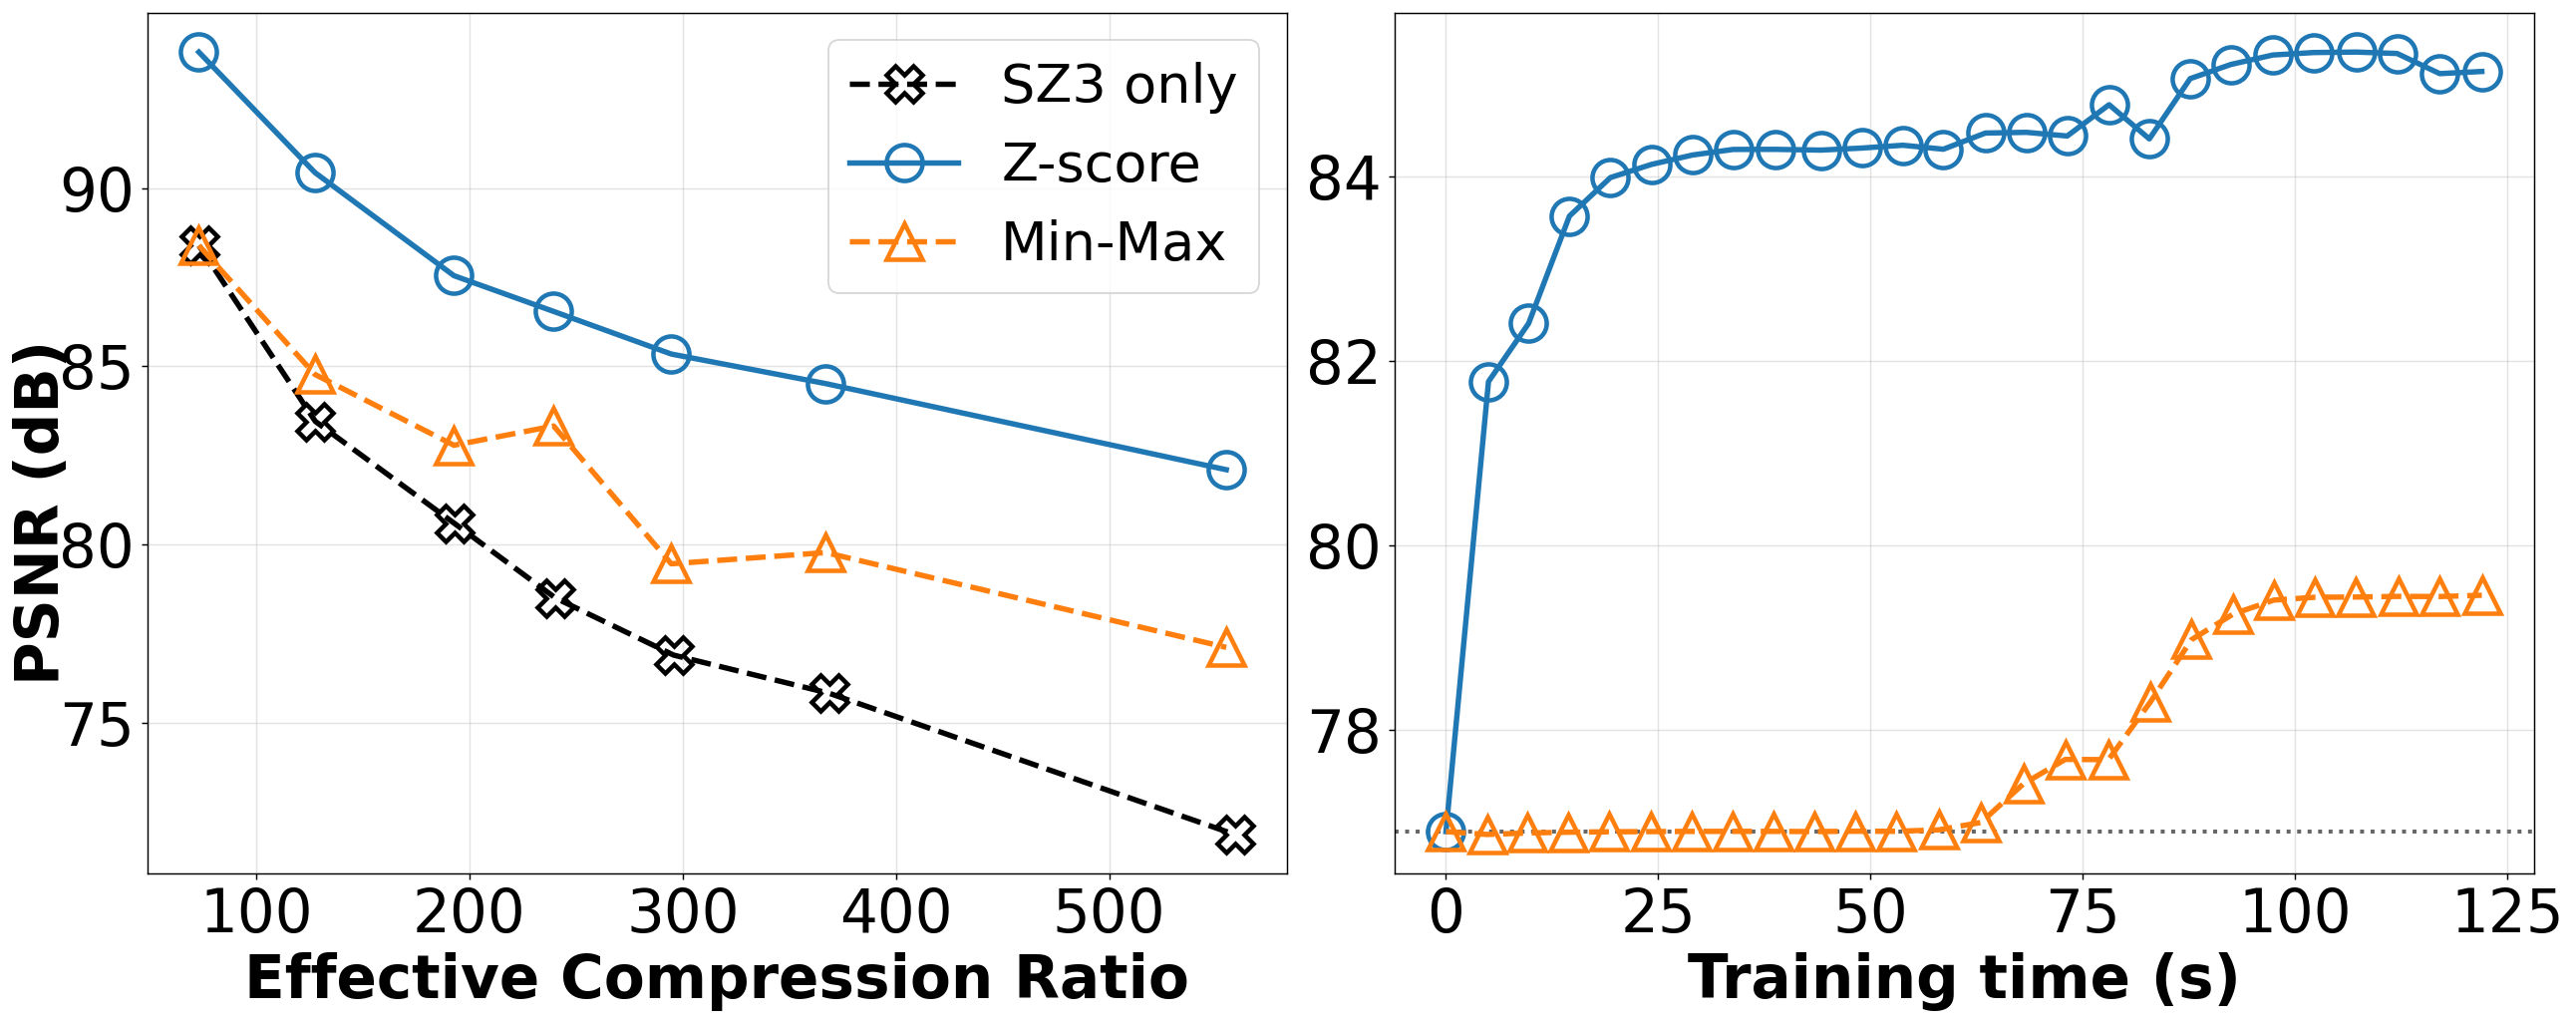

Saved: norm_cr_time_temperature.pdf


In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

PSNR_MODE = "best"
INCLUDE_AUX_BYTES = False
x_true = np.asarray(Xs[0], np.float32)
original_target_bytes = int(x_true.nbytes)
aux_bytes = int(sum(np.asarray(f, np.float32).nbytes for f in Xs[1:])) if (INCLUDE_AUX_BYTES and len(Xs) > 1) else 0

for r in results_compare:
    patch_sz3_bytes(r)

def rows_for_panel(panel):
    rows = []
    for tag, rel in REL_SETTINGS:                                  # SZ3-only baseline
        Xps_rel, _, b = build_Xps_for_rel(float(rel))
        tot = float(len(b)) + aux_bytes
        rows.append({"label": "SZ3 only", "rel_err": float(rel),
                     "effective_cr": float(original_target_bytes / tot),
                     "psnr": float(psnr_np(x_true, np.asarray(Xps_rel[0], np.float32)))})
    for r in results_compare:                                      # trained variants
        if r.get("ablation_panel") != panel:
            continue
        rel = float(r.get("rel_err", float("nan")))
        if not np.isfinite(rel):
            continue
        nn_b = float(model_param_bytes(r.get("model"), dtype_bytes=MODEL_DTYPE_BYTES))
        tot  = float(r["sz3_bytes"]) + nn_b + aux_bytes
        rows.append({"label": str(r.get("ablation_tag", "?")), "rel_err": rel,
                     "effective_cr": float(original_target_bytes / tot),
                     "psnr": float(get_run_psnr(r, mode=PSNR_MODE))})
    return pd.DataFrame(rows)

NORM_COLORS = {"zscore": "#1f77b4", "minmax": "#ff7f0e"}
NORM_LABELS = {"zscore": "Z-score", "minmax": "Min-Max"}
TIME_REL = REL_SETTINGS[4][1]     # representative rel for the time panel

fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=130)

# 统一的样式定义：(颜色, 线条样式, 形状)
sty = {"SZ3 only": ("black", "--", "X"),
       "zscore":   (NORM_COLORS["zscore"], "-", "o"),
       "minmax":   (NORM_COLORS["minmax"], "--", "^")}  # minmax 改成了虚线和三角形

# ── Left: PSNR vs Compression Ratio (rel sweep) ──
ax = axes[0]
df = rows_for_panel("norm").replace([np.inf, -np.inf], np.nan).dropna(subset=["effective_cr", "psnr"])
best = df.groupby(["label", "rel_err"], as_index=False).agg({"effective_cr": "mean", "psnr": "max"})

for lab in ["SZ3 only", "zscore", "minmax"]:
    g = best[best["label"] == lab].sort_values("effective_cr")
    if g.empty:
        continue
    c, ls, mk = sty[lab]
    ax.plot(g["effective_cr"], g["psnr"], marker=mk, ls=ls, color=c, lw=3,
            ms=20, mfc="none", mew=2.5, label=NORM_LABELS.get(lab, lab))
            
ax.set_xlabel("Effective Compression Ratio", fontsize=33, fontweight="bold")
# 【改动 1】：注释掉独立的 y 轴标签
# ax.set_ylabel("PSNR (dB)", fontsize=33, fontweight="bold")
# ax.set_title(f"PSNR vs Compression Ratio  ({TARGET_STEM})", fontsize=19, fontweight="bold")
ax.grid(True, alpha=0.35); ax.legend(fontsize=30); ax.tick_params(labelsize=33)

# ── Right: PSNR vs training time at TIME_REL (100 epochs, same for both) ──
ax = axes[1]

# ── starting PSNR: SZ3-only baseline at TIME_REL (before any training; norm-independent) ──
_Xps_t0, _, _ = build_Xps_for_rel(float(TIME_REL))
start_psnr = float(psnr_np(x_true, np.asarray(_Xps_t0[0], np.float32)))
ax.axhline(start_psnr, color="0.4", linestyle=":", linewidth=2.2, zorder=1, label="SZ3 only")
# ax.text(0.98, start_psnr, f"starting PSNR = {start_psnr:.2f} dB",
#         transform=ax.get_yaxis_transform(), ha="right", va="bottom",
#         fontsize=24, color="0.3")

for norm in ["zscore", "minmax"]:
    run = next((r for r in results_compare
                if r.get("ablation_panel") == "norm" and r.get("ablation_tag") == norm
                and abs(float(r.get("rel_err", -1.0)) - float(TIME_REL)) < 1e-12), None)
    if run is None:
        continue
    h = run.get("hist", {})
    t = list(h.get("time", []))
    p = [pp for (_, pp) in h.get("psnr", [])]
    n = min(len(t), len(p))
    if n == 0:
        continue
        
    # Epoch 0 (未训练前的初始点): time = 0, PSNR = start_psnr
    t_plot = [0.0] + t[:n]
    p_plot = [start_psnr] + p[:n]
        
    # 直接调用我们在上方统一定义的 sty 字典，确保左右图一致
    c, ls, mk = sty[norm]
    # 使用和左图一致的参数：mfc="none" (空心), mew=2.5 (粗边缘)
    ax.plot(t_plot, p_plot, marker=mk, ls=ls, color=c, lw=3, 
            ms=20, mfc="none", mew=2.5, label=NORM_LABELS[norm])

ax.set_xlabel("Training time (s)", fontsize=33, fontweight="bold")
# 【改动 2】：注释掉独立的 y 轴标签
# ax.set_ylabel("PSNR (dB)", fontsize=33, fontweight="bold")
# ax.set_title(f"PSNR vs Time  (rel={TIME_REL:.0e}, 100 epochs)", fontsize=19, fontweight="bold")
ax.grid(True, alpha=0.35)
ax.tick_params(labelsize=33)
# ax.legend(fontsize=28, loc ='lower right', bbox_to_anchor=(1, 0.05))

# 【改动 3】：添加全局共享的 y 轴标签
fig.supylabel("PSNR (dB)", fontsize=33, fontweight="bold")

plt.tight_layout()
save_filename = f"norm_cr_time_{TARGET_STEM}.pdf"
plt.savefig(save_filename, format="pdf", bbox_inches="tight")
plt.show()
print("Saved:", save_filename)



==== [PSNR vs time] z-score | rel=5e-04 ====
  [zscore] ep   1/100 | MSE 1.010282 | PSNR 76.93 dB | t=1.2s
  [zscore] ep   2/100 | MSE 0.798404 | PSNR 79.45 dB | t=2.4s
  [zscore] ep   3/100 | MSE 0.475442 | PSNR 79.90 dB | t=3.6s
  [zscore] ep   4/100 | MSE 0.376062 | PSNR 81.70 dB | t=4.7s
  [zscore] ep   5/100 | MSE 0.319060 | PSNR 81.28 dB | t=5.9s
  [zscore] ep   6/100 | MSE 0.293151 | PSNR 82.50 dB | t=7.1s
  [zscore] ep   7/100 | MSE 0.277077 | PSNR 82.57 dB | t=8.3s
  [zscore] ep   8/100 | MSE 0.253925 | PSNR 82.06 dB | t=9.5s
  [zscore] ep   9/100 | MSE 0.250358 | PSNR 83.22 dB | t=10.6s
  [zscore] ep  10/100 | MSE 0.232130 | PSNR 83.35 dB | t=11.8s
  [zscore] ep  11/100 | MSE 0.222882 | PSNR 83.28 dB | t=13.0s
  [zscore] ep  12/100 | MSE 0.216448 | PSNR 83.75 dB | t=14.3s
  [zscore] ep  13/100 | MSE 0.209689 | PSNR 83.65 dB | t=15.5s
  [zscore] ep  14/100 | MSE 0.205833 | PSNR 83.49 dB | t=16.7s
  [zscore] ep  15/100 | MSE 0.203259 | PSNR 84.03 dB | t=17.9s
  [zscore] ep  16

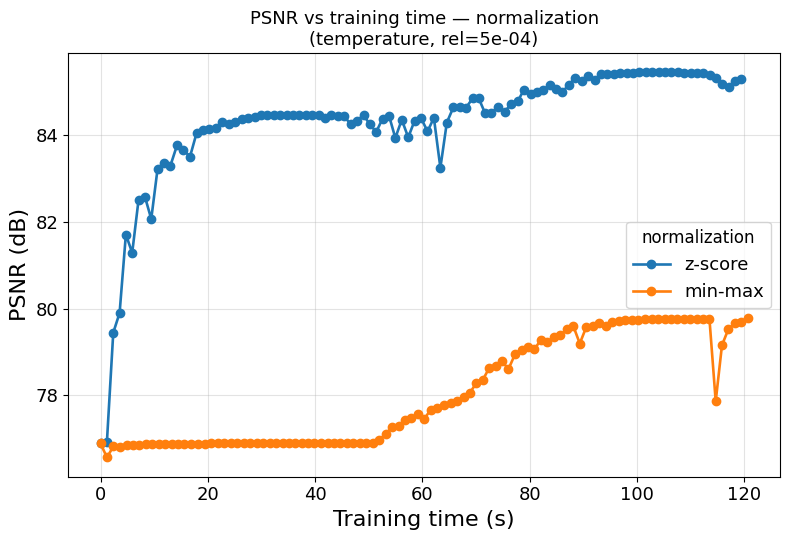

Saved: psnr_vs_time_norm_temperature.pdf
   z-score (zscore): best PSNR= 85.43 dB | 100 epochs | 119.4s train
   min-max (minmax): best PSNR= 79.77 dB | 100 epochs | 120.6s train


In [8]:
# ── PSNR vs training time : normalization ablation (min-max vs z-score) ────────
# Same BasicUNet / LR / batch / features / SEED; ONLY the normalization differs
# (pure MSE on the normalized SZ3 residual, no frequency loss). Reuses the helpers
# from the ablation cell (_norm_fit / _norm_inv / BU_*), but records per-epoch
# cumulative TRAINING wall-clock (PSNR-eval time excluded) so we can plot PSNR vs
# time. t=0 anchor = the SZ3 base PSNR (before any training), shared by both curves.
import time as _time
import matplotlib.pyplot as plt

NORM_REL_ERR = 5e-4                    # SZ3 base bound to train at
NORM_EPOCHS  = int(globals().get("NORM_EPOCHS", BU_EPOCHS))    # epochs per variant
NORM_COLORS  = {"zscore": "tab:blue",   "minmax": "tab:orange"}
NORM_LABELS  = {"zscore": "z-score",    "minmax": "min-max"}

def run_basicunet_norm_timed(rel_err, norm, epochs):
    """Train the BasicUNet residual model under one normalization scheme and return
    (times, psnrs): cumulative training seconds (eval excluded) vs global PSNR."""
    Xps_rel, _sz_ratio, _sz_bytes = build_Xps_for_rel(float(rel_err))
    # NeurLZ nyx order='zxy' -> transpose(2,0,1) so the UNet trains on the same slices.
    _zxy = lambda a: np.ascontiguousarray(np.transpose(np.asarray(a, np.float32), (2, 0, 1)))
    lq  = _zxy(Xps_rel[0])
    tgt = _zxy(gt_target)
    fields = [lq] + [_zxy(a) for a in Xps_rel[1:]]
    D, H, W = tgt.shape
    lq_n = np.stack([_norm_fit(f, norm)[0] for f in fields], axis=1)
    err_n, err_p = _norm_fit(tgt - lq, norm)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yer = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff = max(1, min(BU_BATCH, BU_MAX_PIXELS_PER_BATCH // (H * W)))

    set_seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(BU_FEAT), act="gelu",
                          in_channels=len(fields), out_channels=1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=BU_LR)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse = torch.nn.MSELoss()
    idx = np.arange(D)

    def _psnr_now():
        model.eval(); out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff):
                bi = list(range(st, min(st + eff, D)))
                pr = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + _norm_inv(pr, err_p)
        model.train()
        # considerOEB=False in train.py -> no error-bound clamping before PSNR.
        return _global_diag(tgt, out)["psnr"]

    base_psnr = _global_diag(tgt, lq)["psnr"]     # SZ3-only anchor (no model)
    times, psnrs = [0.0], [base_psnr]
    cum_train = 0.0
    model.train()
    for ep in range(int(epochs)):
        t0 = _time.perf_counter()
        np.random.shuffle(idx); tot = nb = 0
        for st in range(0, D, eff):
            bi = idx[st:st + eff]
            loss = mse(model(Xlq[bi].to(device)), Yer[bi].to(device))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
            tot += float(loss.item()); nb += 1
        cum_train += _time.perf_counter() - t0     # eval below is NOT counted
        p = _psnr_now()
        times.append(cum_train); psnrs.append(p)
        print(f"  [{norm}] ep {ep+1:3d}/{epochs} | MSE {tot/max(nb,1):.6f} | "
              f"PSNR {p:.2f} dB | t={cum_train:.1f}s")

    model.to("cpu"); del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return times, psnrs

norm_time_runs = {}
for norm in ["zscore", "minmax"]:
    print(f"\n==== [PSNR vs time] {NORM_LABELS[norm]} | rel={NORM_REL_ERR:.0e} ====")
    norm_time_runs[norm] = run_basicunet_norm_timed(NORM_REL_ERR, norm, NORM_EPOCHS)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
for norm in ["zscore", "minmax"]:
    t, psnr = norm_time_runs[norm]
    ax.plot(t, psnr, marker="o", markersize=6, linewidth=1.9,
            color=NORM_COLORS[norm], label=NORM_LABELS[norm])

ax.set_xlabel("Training time (s)", fontsize=16)
ax.set_ylabel("PSNR (dB)", fontsize=16)
ax.set_title(f"PSNR vs training time — normalization\n"
             f"({TARGET_STEM}, rel={NORM_REL_ERR:.0e})", fontsize=13)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=13, title="normalization", title_fontsize=12)
plt.tight_layout()
out_pdf = f"psnr_vs_time_norm_{TARGET_STEM}.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_pdf)

for norm in ["zscore", "minmax"]:
    t, psnr = norm_time_runs[norm]
    print(f"  {NORM_LABELS[norm]:>8} ({norm}): best PSNR={max(psnr):6.2f} dB | "
          f"{len(psnr)-1} epochs | {t[-1]:.1f}s train")


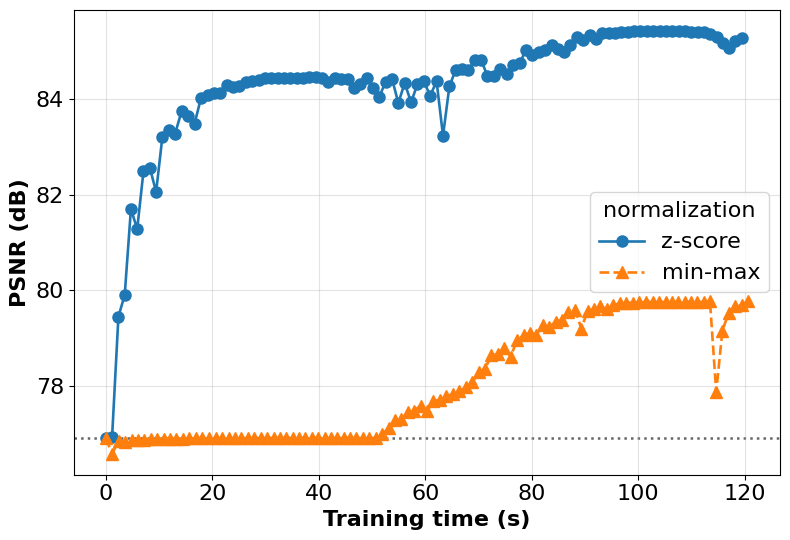

Saved: psnr_vs_time_norm_temperature.pdf


In [9]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))

# 在列表里为每个 norm 配置特定的形状 (mk) 和线条样式 (ls)
for norm, mk, ls in [("zscore", "o", "-"), ("minmax", "^", "--")]:
    t, psnr = norm_time_runs[norm]
    
    # 加入 marker=mk 和 linestyle=ls 
    ax.plot(t, psnr, marker=mk, linestyle=ls, markersize=8, linewidth=1.9,
            color=NORM_COLORS[norm], label=NORM_LABELS[norm])

# ── starting PSNR: SZ3-only baseline at t=0 (before any training), shared by both curves ──
start_psnr = norm_time_runs["zscore"][1][0]
ax.axhline(start_psnr, color="0.4", linestyle=":", linewidth=1.8, zorder=1)
# ax.text(0.98, start_psnr, f"starting PSNR = {start_psnr:.2f} dB",
#         transform=ax.get_yaxis_transform(), ha="right", va="bottom",
#         fontsize=13, color="0.3")

# 【改动在这里】：加上了 fontweight='bold'
ax.set_xlabel("Training time (s)", fontsize=16, fontweight='bold')
ax.set_ylabel("PSNR (dB)", fontsize=16, fontweight='bold')

# ax.set_title(f"PSNR vs training time — normalization\n"
#              f"({TARGET_STEM}, rel={NORM_REL_ERR:.0e})", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=16, title="normalization", title_fontsize=16)
plt.tight_layout()
out_pdf = f"psnr_vs_time_norm_{TARGET_STEM}.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_pdf)